Выбор файла загрузки

In [178]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


Считывание датасета из файла train.csv

In [179]:
import pandas as pd
import numpy as np
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Визуализация распределения значений признаков

Text(0.5, 1.0, 'Визуализация распределения значений признаков')

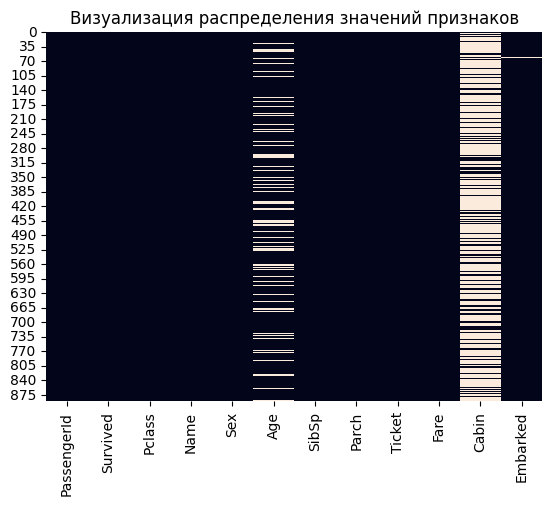

In [181]:
df.isnull().sum()
sns.heatmap(df.isnull(), cbar = False).set_title('Визуализация распределения значений признаков')

График типа boxplot для столбца Age

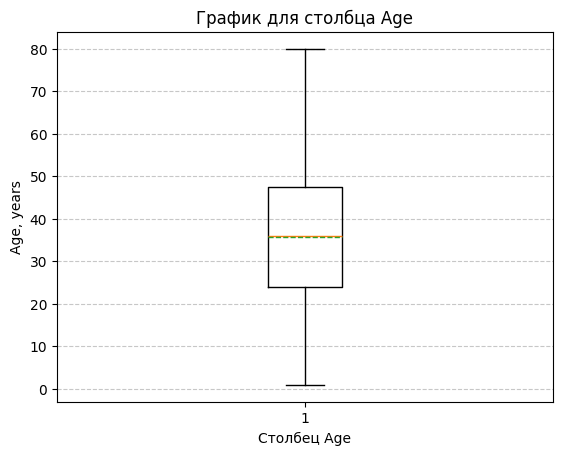

In [188]:
import matplotlib.pyplot as plt
x = df.dropna()['Age']
fig, ax = plt.subplots()
ax.boxplot(x, showmeans=True, meanline=True);
plt.title('График для столбца Age')
plt.xlabel('Столбец Age')
plt.ylabel('Age, years')
plt.grid(axis='y', linestyle='--', alpha=0.7)

Интепретация графика для столбца Age: медиана примерно в центре ящика, верхний ус немного длиннее, нет точек за пределами усов.

График типа pie chart для переменных Survived, Pclass с подписанными долями в процентах

Text(0.5, 1.0, 'Процент выживших')

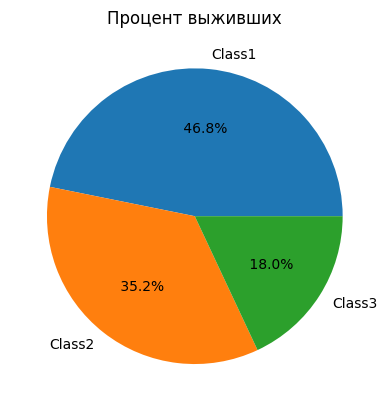

In [184]:
Class_People = df.groupby('Pclass')['Pclass'].value_counts()
Surv = df.groupby('Pclass')['Survived'].sum()
labels= ['Class1', 'Class2', 'Class3']
value = Surv/Class_People*100
fig, ax = plt.subplots()
ax.pie(value, labels = labels, autopct = ' %1.1f%%');
plt.title("Процент выживших")

График типа pairplot для числовых переменных датасета

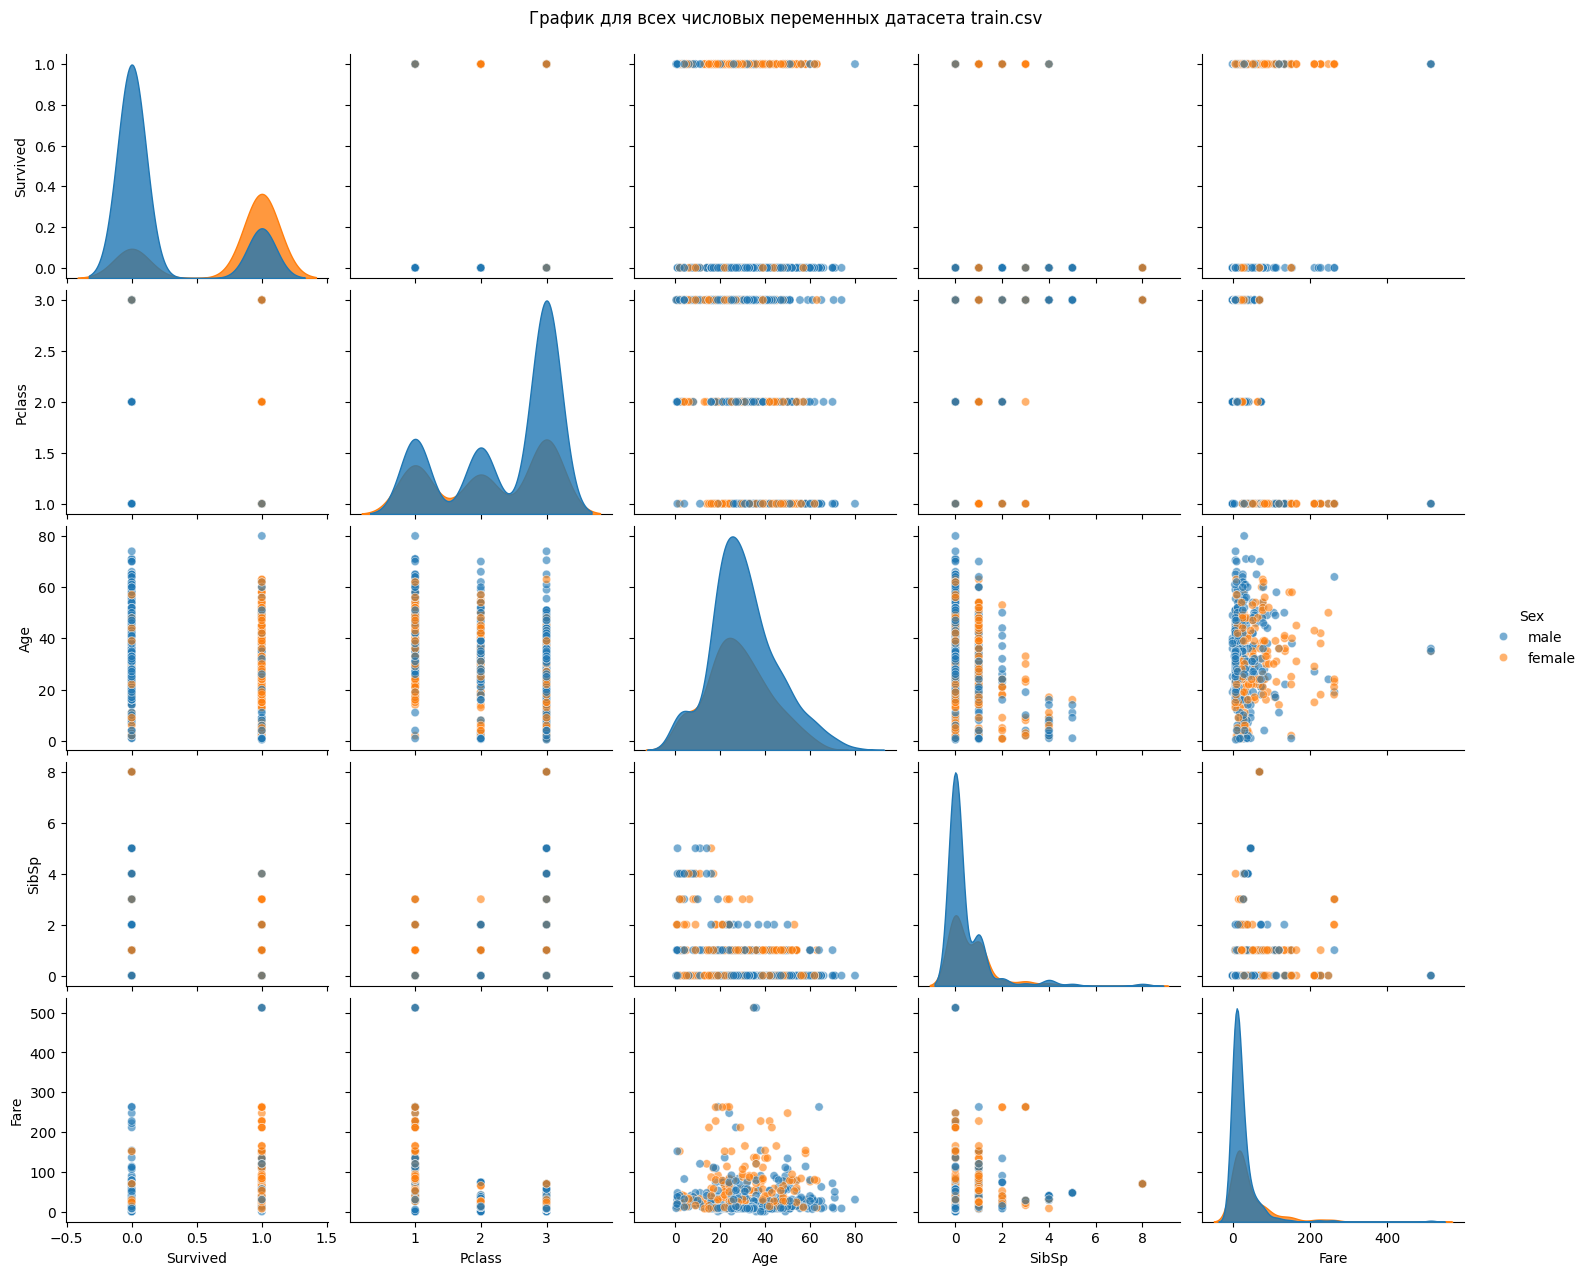

In [185]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(
df,
hue = 'Sex',
vars = ['Survived', 'Pclass', 'Age', 'SibSp', 'Fare'],
diag_kind = 'kde',
height = 2.5,
aspect = 1.2,
plot_kws = {'alpha': 0.6},
diag_kws = {'alpha': 0.8}
)
plt.suptitle('График для числовых переменных датасета train.csv', y = 1.02)
plt.show()

Интерактивный sunburst plot (визуализация иерархических данных) с помощью plotly. На первом уровне иерархии - количество пассажиров в каждом из классов, а на втором количество женщин/мужчин в этом классе

Вариант 1

In [176]:
import plotly.express as px
fig = px.sunburst(df, path = ['Pclass', 'Sex'])
fig.update_layout(title_text='Пассажиры Титаника', title_x=0.5)
fig.show()

Вариант 2

In [191]:
Class_P = ['Class 1', 'Class 1', 'Class 2', 'Class 2', 'Class 3', 'Class 3']
Sex_P = ['male', 'female', 'male', 'female', 'male', 'female']
Class_People_Sex = df.groupby('Pclass')['Sex'].value_counts()
df1 = pd.DataFrame(dict(sex = Sex_P, pclass = Class_P, data = Class_People_Sex))
fig = px.sunburst(df1, path=['pclass', 'sex'], values='data')
fig.update_layout(title_text='Пассажиры Титаника', title_x=0.5)
fig.show()